# Music

### Imports

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load music.csv

In [63]:
music = pd.read_csv("music.csv")

#### Head and Tail

In [64]:
print("HEAD:")
music.head()

HEAD:


,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,223988.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,210943.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,173865.0
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0


In [65]:
print("TAIL:")
music.tail()


TAIL:


,title,rank,date,artist,url,region,chart,trend,streams
26173480,BYE,46,2021-07-31,Jaden,https://open.spotify.com/track/3OUyyDN7EZrL7i0...,Vietnam,viral50,MOVE_UP,9565.0
26173481,Pillars,47,2021-07-31,My Anh,https://open.spotify.com/track/6eky30oFiQbHUAT...,Vietnam,viral50,NEW_ENTRY,9565.0
26173482,Gái Độc Thân,48,2021-07-31,Tlinh,https://open.spotify.com/track/2klsSb2iTfgDh95...,Vietnam,viral50,MOVE_DOWN,9565.0
26173483,Renegade (feat. Taylor Swift),49,2021-07-31,Big Red Machine,https://open.spotify.com/track/1aU1wpYBSpP0M6I...,Vietnam,viral50,MOVE_DOWN,9565.0
26173484,Letter to Jarad,50,2021-07-31,"LRN Slime, Shiloh Dynasty",https://open.spotify.com/track/508QhA2SncMbh5C...,Vietnam,viral50,MOVE_DOWN,9565.0


### Info - data types, null values

In [66]:
music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26173485 entries, 0 to 26173484
Data columns (total 9 columns):
 #   Column   Dtype  
---  ------   -----  
 0   title    object 
 1   rank     int64  
 2   date     object 
 3   artist   object 
 4   url      object 
 5   region   object 
 6   chart    object 
 7   trend    object 
 8   streams  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 1.8+ GB


#### Describe - basic statistics

In [67]:
music.describe()

,rank,streams
count,2.617348e+07,2.617348e+07
mean,8.092316e+01,4.504503e+04
std,5.918601e+01,1.856572e+05
min,1.000000e+00,1.001000e+03
25%,2.900000e+01,4.850000e+03
50%,6.700000e+01,9.565000e+03
75%,1.310000e+02,2.489900e+04
max,2.000000e+02,1.974970e+07


#### Column names

In [68]:
print("COLUMNS:", music.columns.tolist())

COLUMNS: ['title', 'rank', 'date', 'artist', 'url', 'region', 'chart', 'trend', 'streams']


#### Sample

In [69]:
music.sample(5)

,title,rank,date,artist,url,region,chart,trend,streams
22892686,"Sola (Remix) [feat. Daddy Yankee, Wisin, Farru...",62,2018-01-03,Anuel AA,https://open.spotify.com/track/5q2JbCNi4Fcnglg...,Dominican Republic,top200,SAME_POSITION,2240.0
21328853,Bank Account,121,2017-10-04,21 Savage,https://open.spotify.com/track/2fQrGHiQOvpL9Ug...,Italy,top200,MOVE_DOWN,21029.0
22326319,PLAYING WITH FIRE,145,2021-09-10,BLACKPINK,https://open.spotify.com/track/7qmvLmX9tyaTiBA...,Thailand,top200,NEW_ENTRY,8382.0
21238245,Sígueme Bailando,116,2017-09-03,"Juan Magán, Nacho, Pasabordo",https://open.spotify.com/track/1fiwHsiitsbudIj...,Spain,top200,MOVE_DOWN,25095.0
3500725,ديناميت,6,2020-06-22,"Molotof, Marwan Pablo",https://open.spotify.com/track/5twYD0NescUAuES...,Egypt,top200,MOVE_UP,3856.0


#### Normalization

In [70]:
# compute once
min_val = music['streams'].min()
max_val = music['streams'].max()

# apply normalization
music['streams_norm'] = (music['streams'] - min_val) / (max_val - min_val)

music[['streams', 'streams_norm']].head()


,streams,streams_norm
0,253019.0,0.012761
1,223988.0,0.011291
2,210943.0,0.010631
3,173865.0,0.008753
4,153956.0,0.007745


Normalization scales the streams values between 0 and 1. The minimum stream value becomes 0 and the maximum becomes 1. This helps in comparing values across the dataset without being affected by large magnitude differences.

#### Standardization

In [71]:
# compute once
mean_val = music['streams'].mean()
std_val = music['streams'].std()

# apply standardization
music['streams_std'] = (music['streams'] - mean_val) / std_val

# check
music[['streams', 'streams_std']].head()

,streams,streams_std
0,253019.0,1.120204
1,223988.0,0.963835
2,210943.0,0.893571
3,173865.0,0.693859
4,153956.0,0.586624


Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1. This allows us to understand how far each value is from the average in terms of standard deviations.

In [72]:
music.columns.tolist()

['title',
 'rank',
 'date',
 'artist',
 'url',
 'region',
 'chart',
 'trend',
 'streams',
 'streams_norm',
 'streams_std']

### Year – Region – Song – Artist – Streams (Top 10 Analysis)

In [73]:
music['date'] = pd.to_datetime(music['date'])
music['year'] = music['date'].dt.year

In [11]:
top_correct = (
    music.groupby(['year', 'region', 'title', 'artist'])['streams']
    .sum()
    .reset_index()
)

top_correct = top_correct.sort_values(
    ['year', 'region', 'streams'],
    ascending=[True, True, False]
)


top10_correct = (
    top_correct
    .groupby(['year', 'region'])
    .head(10)
)
top10_correct

,year,region,title,artist,streams
616,2017,Andorra,I Feel It Coming,"The Weeknd, Daft Punk",334775.0
744,2017,Andorra,La flama,"Obrint Pas, Xavi Sarrià",267820.0
848,2017,Andorra,Me Enamoré,Shakira,219995.0
613,2017,Andorra,I Don't Want to Miss a Thing - From the Touchs...,Aerosmith,200865.0
1572,2017,Andorra,"Yo Contigo, Tú Conmigo - The Gong Gong Song / ...","Morat, Alvaro Soler",200865.0
...,...,...,...,...,...
692679,2021,Vietnam,At My Worst,Pink Sweat$,6868541.0
692954,2021,Vietnam,Dynamite,BTS,6534373.0
694158,2021,Vietnam,Đi Về Nhà,"Đen, JustaTee",6160091.0
692898,2021,Vietnam,Cứ Chill Thôi,"Chillies, Suni Hạ Linh, Rhymastic",5882962.0


The analysis shows that top-streamed songs differ across years and regions, with global hits consistently dominating overall charts. However, regional tracks also appear in certain countries, indicating a mix of global popularity and local music preferences.

## Dataset Overview

### SUM – Total Streams

In [75]:
music["streams"].sum()

np.float64(1178985490738.0)

The total number of streams in the dataset is approximately 1.17 trillion, indicating a very large scale of music consumption.

This high value reflects the global reach of the dataset. However, previous analyses show that streams are not evenly distributed. A small number of highly popular songs contribute significantly to this total, while the majority of songs have relatively low stream counts.

### Unique Artists

In [76]:
music["artist"].nunique()

96156

The dataset contains 96,156 unique artists, indicating a high level of diversity in music content.

Despite this large number of artists, previous analyses show that streaming activity is highly concentrated. Only a small subset of artists generates the majority of streams, while most artists have relatively low visibility.

### Unique Songs

In [77]:
music["title"].nunique()

164805

The dataset contains 164,805 unique songs, reflecting a wide range of musical content.

This high number highlights the extensive coverage of the dataset and suggests that it includes both popular and less prominent tracks.

Additionally, the large number of songs compared to the number of artists suggests that many artists have multiple tracks represented, enabling deeper analysis of artist performance and consistency.

### Unique Regions

In [78]:
music["region"].nunique()

70

The dataset includes 70 unique regions, indicating broad geographic coverage of music streaming data.

This wide range of regions enables meaningful comparisons between countries and allows the analysis of how music preferences vary across different markets. It also supports the identification of both global trends and region-specific patterns.

Overall, the dataset provides a solid foundation for studying the geographic distribution of music consumption.

## Statistical Analysis

### Average

In [79]:
music.select_dtypes(include='number').mean()

rank            8.092316e+01
streams         4.504503e+04
streams_norm    2.230224e-03
streams_std    -1.334350e-17
year            2.019135e+03
dtype: float64

The average rank is approximately 80.92, which indicates that most songs are not positioned at the very top of the charts. Instead, they tend to appear in mid to lower rankings, suggesting that only a small proportion of songs achieve top positions.


The average number of streams is around 45,045. This suggests a moderate level of listening activity overall. However, this value is likely influenced by a small number of highly popular songs with very high streams, which increases the average. This indicates a skewed distribution, where a few songs dominate in popularity while the majority receive fewer streams.

### Variance (var)

In [80]:
music.select_dtypes(include='number').var()

rank            3.502984e+03
streams         3.446861e+10
streams_norm    8.837850e-05
streams_std     1.000000e+00
year            1.933157e+00
dtype: float64

The variance of the rank is approximately 3502.98, indicating a moderate spread of ranking positions across the dataset. This suggests that songs are distributed across different positions in the charts rather than being concentrated in a specific ranking range.

In contrast, the variance of streams is extremely high (3.44 × 10¹⁰), revealing a very large dispersion in the number of streams. This indicates that while some songs achieve very high streaming numbers, the majority receive significantly fewer streams.

This pattern reflects a highly uneven distribution, where a small number of popular tracks dominate total streams, while most songs remain relatively less listened. Such behavior is typical in large-scale music platforms.

### Maximum

In [81]:
music.select_dtypes(include='number').max()

rank            2.000000e+02
streams         1.974970e+07
streams_norm    1.000000e+00
streams_std     1.061346e+02
year            2.021000e+03
dtype: float64

The maximum rank value is 200, confirming the upper limit of the chart range. This indicates that the dataset includes songs across the full ranking spectrum.

The maximum number of streams is 19,749,704, which represents extremely high popularity for certain tracks. This shows that a small number of songs achieve massive global reach and dominate the dataset in terms of streaming numbers.

### Minimum

In [82]:
music.select_dtypes(include='number').min()

rank               1.000000
streams         1001.000000
streams_norm       0.000000
streams_std       -0.237233
year            2017.000000
dtype: float64

The minimum rank value is 1, representing the top position in the charts. This confirms that the dataset includes the highest-performing songs.

The minimum number of streams is 1,001, which is significantly lower compared to the maximum. This highlights a large gap between the least and most popular songs, reinforcing the presence of a highly uneven distribution of streams.

### Standard Deviation

In [83]:
music.select_dtypes(include='number').std()

rank                59.186009
streams         185657.241202
streams_norm         0.009401
streams_std          1.000000
year                 1.390380
dtype: float64

The standard deviation of the rank is approximately 59.18, indicating that songs are widely distributed across different chart positions. This suggests that rankings are not concentrated in a narrow range, but instead spread throughout the entire chart.

In contrast, the standard deviation of streams is very high (185,657), significantly exceeding the mean. This indicates a high level of variability in streaming counts, where some songs have extremely high values compared to others. This reflects the presence of outliers and reinforces the unequal distribution of popularity among songs.

### Median

In [84]:
music.select_dtypes(include='number').median()

rank              67.000000
streams         9565.000000
streams_norm       0.000434
streams_std       -0.191105
year            2019.000000
dtype: float64

The median rank is 67, meaning that half of the songs are ranked above this position and half below. Compared to the average rank (80.92), this suggests a slight asymmetry in the distribution of rankings.

The median number of streams is 9,565, which is significantly lower than the mean (45,045). This large difference indicates that most songs have relatively low streaming numbers, while a small number of highly popular tracks significantly increase the average.

This confirms the presence of a skewed distribution, where the majority of songs receive modest engagement, while a few dominate in terms of popularity.

### Mean Absolute Deviation (MAD)

In [85]:
music_numeric = music.select_dtypes(include='number')

mad = (music_numeric - music_numeric.mean()).abs().mean()
mad

rank               51.800512
streams         57791.970051
streams_norm        0.002926
streams_std         0.311283
year                1.195676
dtype: float64


The mean absolute deviation (MAD) measures the average distance between each value and the mean, providing a robust view of variability.

The MAD for rank is approximately 51.8, indicating that song positions vary significantly across the chart. This suggests that rankings are widely distributed rather than concentrated around the average.

For streams, the MAD is around 57,792, which is relatively high compared to the mean. This indicates a substantial variation in the number of streams across songs.

When compared to the standard deviation (185,657), the MAD is significantly lower, suggesting that extreme values (outliers) are strongly influencing the standard deviation. This confirms the presence of highly popular songs that dominate streaming counts, while most songs receive comparatively fewer streams.

This difference between MAD and standard deviation highlights the impact of outliers and reinforces the presence of a long-tail distribution in the dataset.

### First Quartile (Q1)

In [86]:
music.select_dtypes(include='number').quantile(0.25)

rank              29.000000
streams         4850.000000
streams_norm       0.000195
streams_std       -0.216501
year            2018.000000
Name: 0.25, dtype: float64

The first quartile (Q1) shows that 25% of the songs have a rank below 29 and fewer than 4,850 streams. This indicates that only a small portion of songs achieve relatively good chart positions and moderate streaming numbers.

### Second Quartile (Q2)

In [87]:
music.select_dtypes(include='number').quantile(0.50)

rank              67.000000
streams         9565.000000
streams_norm       0.000434
streams_std       -0.191105
year            2019.000000
Name: 0.5, dtype: float64

The second quartile (Q2), which corresponds to the median, indicates that 50% of the songs are ranked below position 67 and have fewer than 9,565 streams. This suggests that the majority of songs have relatively low streaming activity.

### Third Quartile (Q3)

In [88]:
music.select_dtypes(include='number').quantile(0.75)

rank              131.000000
streams         24899.000000
streams_norm        0.001210
streams_std        -0.108512
year             2020.000000
Name: 0.75, dtype: float64

The third quartile (Q3) shows that 75% of the songs are ranked below 131 and have fewer than 24,899 streams. This indicates that even among the higher-performing songs, most do not reach extremely high streaming numbers.

### Fourth Quartile (Q4)

In [89]:
music.select_dtypes(include='number').quantile(1.0)

rank            2.000000e+02
streams         1.974970e+07
streams_norm    1.000000e+00
streams_std     1.061346e+02
year            2.021000e+03
Name: 1.0, dtype: float64

The fourth quartile (Q4) represents the maximum values in the dataset, with a rank of 200 and streams reaching 19,749,704. The large gap between Q3 and Q4 highlights the presence of extreme values, where a small number of songs achieve exceptionally high popularity compared to the majority.

The comparison between quartiles reveals a highly skewed distribution. While most songs have relatively low stream counts, a small number of tracks exhibit extremely high values. This confirms the presence of a long-tail distribution and significant inequality in music popularity.

## GroupBy Analysis

### GroupBy: Artist

In [90]:
music.groupby("artist")["streams"].agg(["sum", "mean", "median", "std", "min", "max"]).sort_values("sum", ascending=False).head(10)


,sum,mean,median,std,min,max
artist,,,,,,
Ed Sheeran,2.380505e+10,61366.347309,9565.0,280334.267372,1001.0,10977389.0
Post Malone,1.959290e+10,92737.796461,9565.0,330813.076951,1001.0,7292777.0
Drake,1.837706e+10,103602.754640,9565.0,411966.240628,1001.0,12384750.0
Billie Eilish,1.740249e+10,69105.472650,9565.0,278075.290884,1001.0,7220348.0
Ariana Grande,1.552421e+10,81743.373559,9565.0,350158.159308,1001.0,12229331.0
Dua Lipa,1.227534e+10,65613.728460,9565.0,284672.251136,1001.0,6100930.0
Juice WRLD,1.223138e+10,100312.314066,9565.0,289422.725229,1001.0,5544528.0
The Weeknd,1.222765e+10,79767.029062,9565.0,351023.241597,1001.0,8453567.0
XXXTENTACION,1.220035e+10,78480.031848,8364.0,254981.436906,1001.0,10415088.0


The table summarizes the total, average, median, standard deviation, minimum, and maximum streams per artist. A few key insights stand out:

Highly skewed distribution: The sum of streams shows that a small number of top artists, like Ed Sheeran, Post Malone, and Drake, dominate the total streaming numbers. This indicates that a few artists achieve massive global reach.
Median vs. mean: Almost all artists have a median of 9,565 streams, while their mean varies widely. This highlights a typical long-tail pattern in music streaming: most songs accumulate a modest number of streams, while a few hits dramatically increase the average.
Standard deviation: The large standard deviations reflect the presence of extreme hits for each artist. These outliers create significant variability, confirming the unequal distribution of streams across tracks.
Minimum and maximum: While the minimum streams for almost all artists are very low (around 1,001), the maximum streams can reach tens of millions. This wide range further emphasizes that global hits are rare, but they disproportionately impact total streaming numbers.

Conclusion:
Artist-level metrics reveal a highly unequal and skewed popularity distribution. Most songs by top artists perform moderately, with the majority clustered around similar stream counts, while a few viral hits push the totals and averages far above typical values. This pattern reflects the classic “long-tail” phenomenon in music consumption, where a small number of songs dominate audience attention while most songs achieve only modest engagement.

### GroupBy: Song (Title)

In [91]:
song_stats = music.groupby("title")["streams"].agg(["sum", "mean", "median", "std", "min", "max"]).sort_values("sum", ascending=False)
# Criar coluna com coeficiente de variação (std / mean)
song_stats["cv"] = song_stats["std"] / song_stats["mean"]
# Ordenar por coeficiente de variação para ver quais músicas têm maior disparidade
song_stats.sort_values("cv", ascending=False).head(10)

,sum,mean,median,std,min,max,cv
title,,,,,,,
OG,3651813.0,5986.578689,3130.0,45641.960294,1020.0,1125242.0,7.624048
TUTU,1565233.0,9207.252941,1536.0,62931.532107,1016.0,776296.0,6.834995
abcdefu,260325489.0,50401.837173,9565.0,341660.013102,1091.0,5222032.0,6.778721
ANTES QUE SE ACABE,41430842.0,15947.206313,3354.0,102465.472035,1003.0,3469139.0,6.425293
Invincible,8095785.0,6476.628000,2454.0,41272.601071,1005.0,1061593.0,6.372545
EL MUNDO ES MÍO,30087573.0,39024.089494,4415.0,226033.365044,1012.0,4886546.0,5.792150
After Dark,74585010.0,23155.855324,9565.0,132537.450265,1001.0,3231888.0,5.723712
Highway to Hell,27037122.0,16297.240506,3411.0,93147.215384,1001.0,1410204.0,5.715521
Do It To It,229633665.0,35047.873168,9565.0,198459.589046,1024.0,3007383.0,5.662529


Song Streams Overview

Most songs have modest streams (median ≈ 9,565), while a few entries reach very high numbers, driving up the total (sum) and mean. High standard deviation and CV show strong variability, indicating a long-tail distribution where a small number of entries dominate overall popularity.

### GroupBy: Region

In [92]:
region_stats = music.groupby("region")["streams"].agg(["sum", "mean", "median", "std", "min", "max"]).sort_values("sum", ascending=False)
region_stats

,sum,mean,median,std,min,max
region,,,,,,
Global,4.401614e+11,974254.654534,806888.0,911939.125517,9565.0,19749704.0
United States,1.430013e+11,314249.174607,261489.0,292184.211565,9565.0,6146233.0
Brazil,5.672680e+10,124828.185138,94920.0,127172.379166,9565.0,2001683.0
Mexico,4.646144e+10,103516.326416,82986.0,105376.633992,9565.0,3680758.0
Germany,4.082436e+10,91089.004259,68259.0,93940.385587,9565.0,2629922.0
...,...,...,...,...,...,...
Egypt,8.580918e+08,4754.787664,2723.0,3679.707835,1001.0,74586.0
United Arab Emirates,8.491686e+08,4268.379931,2157.0,3585.464267,1001.0,27573.0
Andorra,7.612975e+08,9565.000000,9565.0,0.000000,9565.0,9565.0


Region-Based Streams Analysis

The regional analysis shows that the Global dataset dominates overall streams with a sum of over 440 billion, reflecting the aggregation across all regions. The United States, Brazil, Mexico, and Germany are the top-performing individual regions, contributing significantly to global streams.

Median values indicate that most songs in each region have modest stream counts, far below the mean, which highlights the presence of a few extremely popular tracks driving up the averages. For instance, in the Global region, the median is 806,888 while the mean is 974,254, showing a long-tail distribution.

Smaller regions like Egypt, United Arab Emirates, Andorra, Ukraine, and South Korea show much lower totals and averages, indicating that only a limited number of songs reach high popularity there. Andorra is particularly interesting: the median, mean, and max are all the same (9,565), meaning the dataset for that region has uniform streams without variability.

Overall, this shows a highly unequal distribution of music streams across regions, with a small number of tracks achieving exceptional popularity globally and regionally, while the majority have moderate to low streams.

### GroupBy: Region + Artist

In [93]:
top5_per_region = (
    music.groupby(["region", "artist"])["streams"]
    .sum()
    .reset_index()
    .sort_values(["region", "streams"], ascending=[True, False])
    .groupby("region")
    .head(5)
)
countries = ["United States", "Brazil", "Germany", "Mexico", "South Korea"]

top5_selected = top5_per_region[top5_per_region["region"].isin(countries)]
top5_selected

,region,artist,streams
33057,Brazil,Marília Mendonça,1.828641e+09
34806,Brazil,Zé Neto & Cristiano,1.732970e+09
32109,Brazil,Jorge & Mateus,1.510257e+09
31787,Brazil,Gusttavo Lima,1.507048e+09
31833,Brazil,Henrique & Juliano,1.499243e+09
96544,Germany,Apache 207,1.077719e+09
97198,Germany,Capital Bra,6.914779e+08
98015,Germany,Ed Sheeran,5.935826e+08
100214,Germany,Luciano,5.078277e+08
99776,Germany,Kontra K,3.949607e+08


This analysis groups the data by region and artist, calculating total streams to identify the top 5 artists in each selected country.

The results show clear regional differences in music popularity. While some global artists appear across multiple regions, each country has its own dominant artists, reflecting local preferences.

For example, markets like the United States and Germany tend to feature internationally popular artists, while regions such as Brazil or South Korea may highlight more localized or regional stars.

Overall, this confirms that music consumption varies significantly by region, combining global trends with strong local influence.

### GroupBy: Region + Song

In [94]:
countries = ["United States", "Brazil", "Germany", "Mexico", "South Korea"]

region_song = (
    music.groupby(["region", "title"])["streams"]
    .sum()
    .reset_index()
)

region_song_filtered = region_song[region_song["region"].isin(countries)]

region_song_sorted = region_song_filtered.sort_values(
    ["region", "streams"], ascending=[True, False]
)

top5_region_song = region_song_sorted.groupby("region").head(5)

top5_region_song

,region,title,streams
55130,Brazil,Meu Abrigo,195407016.0
51719,Brazil,Batom de Cereja - Ao Vivo,193573233.0
54588,Brazil,Lençol Dobrado,193384973.0
56616,Brazil,Recairei - Ao Vivo,188846665.0
53413,Brazil,Facas - Ao Vivo,177726883.0
178926,Germany,Roller,243410534.0
172372,Germany,Dance Monkey,186092692.0
171472,Germany,Blinding Lights,177782398.0
170201,Germany,500 PS,147232834.0
181089,Germany,Vermissen (feat. Henning May),140412274.0


We can see that the US, Brazil, and Mexico have extremely high streams for their top songs, highlighting major regional hits. Germany shows a more balanced distribution among top tracks, while South Korea has lower stream counts overall, reflecting differences in market size or user behavior.

Overall, this analysis reveals how the most popular songs vary across regions and emphasizes the contrast between local and global hits.

### Top 10 Songs by Streams (Artist, Song) - In Descending and Ascending order

#### Song - Descending

In [95]:
music.groupby(["title"])['streams'].sum().sort_values(ascending=False).head(10).reset_index()

,title,streams
0,Shape of You,5.281159e+09
1,Blinding Lights,5.262971e+09
2,Dance Monkey,4.682417e+09
3,Someone You Loved,4.063598e+09
4,Sunflower - Spider-Man: Into the Spider-Verse,3.823160e+09
5,Señorita,3.636238e+09
6,bad guy,3.523698e+09
7,Don't Start Now,3.298516e+09
8,Lucid Dreams,3.233953e+09
9,Happier,3.217228e+09


This chart ranks songs by total streams and clearly shows a strong imbalance in listening behavior. A small number of tracks account for a large share of total streams, while even other top songs fall noticeably behind. This indicates a highly skewed distribution, where only a few songs achieve massive global reach.

#### Song - Ascending

In [96]:
# music.groupby(["title", "artist"])['streams'].sum().sort_values(ascending=True).head(10).reset_index()
music.groupby(["title"])['streams'].sum().sort_values(ascending=True).head(10).reset_index()

,title,streams
0,La Guitarra - MTV Unplugged,1001.0
1,"So Xclusive (feat. K-Slicc, Lo$Ta & Badazz Luck)",1001.0
2,ده و ده,1001.0
3,Vesturbær (feat. Class B),1002.0
4,Hvað Finnst Þér Um Það? (feat. Kilo),1002.0
5,Eső,1002.0
6,Homework As$ignment,1002.0
7,Junkies Ate My Poodle,1002.0
8,Jäätunud Jäljed,1002.0
9,Divata,1002.0


This chart identifies songs with minimal streaming activity. Values are close to zero relative to top performers, confirming the presence of a long tail in the dataset. These observations are consistent with large-scale content platforms where most items receive very low engagement.

#### Artist - Descending

In [97]:
music.groupby("artist")['streams'].sum().sort_values(ascending=False).head(10).reset_index()

,artist,streams
0,Ed Sheeran,2.380505e+10
1,Post Malone,1.959290e+10
2,Drake,1.837706e+10
3,Billie Eilish,1.740249e+10
4,Ariana Grande,1.552421e+10
5,Dua Lipa,1.227534e+10
6,Juice WRLD,1.223138e+10
7,The Weeknd,1.222765e+10
8,XXXTENTACION,1.220035e+10
9,Olivia Rodrigo,9.644647e+09


At the artist level, the same pattern appears as in songs. A limited group of artists generates most of the streams, suggesting consistent performance across multiple songs. The gap between top artists and others highlights unequal audience attention in the dataset.

#### Artist - Ascending

In [98]:
music.groupby("artist")['streams'].sum().sort_values(ascending=True).head(10).reset_index()

,artist,streams
0,"Street Pound Productions, Lota",1001.0
1,"Wegz, Abyusif",1001.0
2,Ragga Holm,1002.0
3,Dossey,1002.0
4,Mark Millar,1002.0
5,RMT EN EL PRODUCTO,1003.0
6,Trey Pearson,1003.0
7,Bear Grillz,1004.0
8,"Oliver Mtukudzi, Ladysmith Black Mambazo",1004.0
9,"Joseph Trapanese, Joey Batey",1004.0


Similar to songs, artist-level aggregation shows that a large number of artists have negligible total streams. This reinforces the long-tail distribution and suggests limited exposure or low chart persistence for most contributors.

### Top 10 Songs by Rank (Artist, Song) - In Descending order

#### Top 10 Songs Appearing in Top 10 (Frequency)

In [99]:
music[music['rank'] <= 10].groupby('title').size().sort_values(ascending=False).head(10).reset_index()

,title,0
0,Dance Monkey,16631
1,Blinding Lights,13066
2,Shape of You,12656
3,Señorita,9482
4,STAY (with Justin Bieber),8516
5,Astronaut In The Ocean,7856
6,Roses - Imanbek Remix,7765
7,Beggin',7423
8,bad guy,7218
9,Calma - Remix,7058


This metric measures how often individual tracks appear within top 10 rankings over time. High values indicate persistence rather than peak performance. The results show that only a limited number of tracks maintain repeated high positions, suggesting strong temporal stability for top-performing songs.

#### Top 10 Songs at Rank 1 (Frequency)

In [100]:
music[music['rank'] == 1].groupby('title').size().sort_values(ascending=False).head(10).reset_index()

,title,0
0,Dance Monkey,4261
1,Shape of You,4172
2,Señorita,2897
3,Despacito - Remix,2598
4,Tusa,2372
5,Calma - Remix,2321
6,rockstar,2222
7,Despacito (Featuring Daddy Yankee),2054
8,STAY (with Justin Bieber),2046
9,DÁKITI,1932


This analysis isolates the number of times a track achieves the top rank. Compared to general top 10 frequency, the distribution is more concentrated. Only a few tracks repeatedly reach rank 1, indicating that peak dominance is even more limited than general high performance.

#### Top 10 Artists Appearing in Top 10 (Frequency)

In [101]:
music[music['rank'] <= 10].groupby('artist').size().sort_values(ascending=False).head(10).reset_index()

,artist,0
0,Ed Sheeran,37003
1,Ariana Grande,21467
2,Drake,20723
3,The Weeknd,20564
4,Lil Nas X,19968
5,Bad Bunny,19041
6,Måneskin,18327
7,Post Malone,17405
8,Billie Eilish,17046
9,Tones And I,16553


This chart evaluates artist-level consistency in achieving top 10 placements. The results indicate that repeated high-ranking presence is concentrated among a small subset of artists. This suggests sustained competitiveness and consistent audience engagement across multiple releases.

#### Top 10 Artists at Rank 1 (Frequency)

In [102]:
music[music['rank'] == 1].groupby('artist').size().sort_values(ascending=False).head(10).reset_index()

,artist,0
0,Ed Sheeran,5450
1,Tones And I,4275
2,Ariana Grande,3857
3,Drake,3545
4,"Shawn Mendes, Camila Cabello",2897
5,Måneskin,2818
6,Lil Nas X,2804
7,"Luis Fonsi, Daddy Yankee, Justin Bieber",2598
8,Maluma,2561
9,Bad Bunny,2513


This metric captures the frequency of artists reaching the top chart position. The distribution is highly concentrated, with a small number of artists dominating rank 1 occurrences. This reflects structural inequality at the highest level of chart performance.

### The most popular artists in each country

In [103]:
pd.set_option('display.max_rows', 100)

(music.groupby(['region', 'artist'])
                .size()
                .reset_index(name='count')
                .sort_values(['region', 'count'], ascending=[True, False])
                .groupby('region').head(1)).sort_values(['count'], ascending=[False])


,region,artist,count
67936,Dominican Republic,Bad Bunny,19055
116713,Honduras,Bad Bunny,17355
193146,New Zealand,SIX60,14708
76718,El Salvador,Bad Bunny,14418
304385,Vietnam,BTS,14242
10029,Australia,Ed Sheeran,13604
204297,Panama,Bad Bunny,13520
238193,Singapore,Ed Sheeran,13435
113100,Guatemala,Bad Bunny,13396
94082,France,Ninho,13029


The data shows the most frequent artists in national music charts across different countries. Some artists appear many times in multiple regions, showing their global presence. For example, Bad Bunny appears often in the charts of countries like the Dominican Republic, Honduras, El Salvador, Panama, and Mexico, sometimes appearing more than ten thousand times.

Ed Sheeran is also very common in charts across Australia, Ireland, Singapore, Denmark, and several European countries. BTS appears frequently in Vietnam and South Korea, while Juice WRLD is prominent in the United States. Some artists are more localized. Marília Mendonça leads in Brazil, Ezhel in Turkey, and Arijit Singh in India.

These numbers show how music trends differ between countries. Latin music, pop, and K-pop dominate many regions, but local artists continue to be very important. Overall, the charts highlight both international stars and regional favorites, giving a clear picture of music trends around the world.

In [104]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

### Correlation Analysis

#### Correlation (Rank vs Streams)

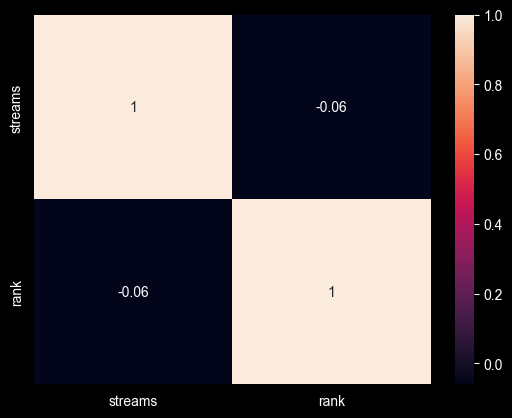

In [105]:
sns.heatmap( music[['streams', 'rank']].corr(), annot=True)
plt.show()

The correlation between rank and streams is slightly negative. This means that lower ranks (closer to 1) usually have higher streams. However, the relationship is not perfect, which suggests other factors also influence rankings, such as region or time.

### Distribution Plot (Streams vs Rank)

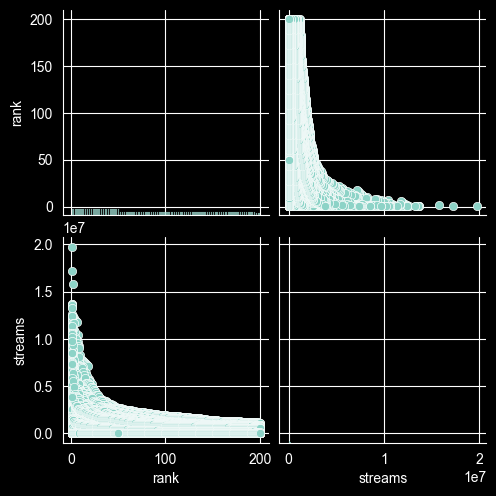

In [106]:
sns.pairplot(music[['rank','streams']])
plt.show()

This graph shows a clear decreasing trend. Most songs have low streams, and only a small number reach very high values. The shape looks like a long tail, which is common in real-world data. It confirms that popularity is concentrated in a few songs, while the majority remain less listened.

### Covariance Analysis

In [107]:
music.select_dtypes(include=['number']).cov()

,rank,streams,streams_norm,streams_std,year
rank,3502.983661,-6.604493e+05,-0.033443,-3.557358,1.958739
streams,-660449.338066,3.446861e+10,1745.360757,185657.241202,2252.501253
streams_norm,-0.033443,1.745361e+03,0.000088,0.009401,0.000114
streams_std,-3.557358,1.856572e+05,0.009401,1.000000,0.012133
year,1.958739,2.252501e+03,0.000114,0.012133,1.933157


The covariance between rank and streams is −660,449, indicating an inverse relationship: as a song’s rank improves (closer to 1), its streams generally increase. The large magnitude reflects the high variance in streams (3.45 × 10¹⁰), making covariance sensitive to scale, while the smaller variance in rank (3502.98) shows that most variability comes from streaming counts rather than ranking. Overall, the negative covariance confirms that higher chart positions tend to correspond with more streams, even if the relationship isn’t perfectly consistent.


## Trend Analysis

In [130]:
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for nicer plots
import numpy as np  # for math operations
import pandas as pd

# convert date column to datetime so we can extract year from it
music['date'] = pd.to_datetime(music['date'])
# extract just the year from the date column
music['year'] = music['date'].dt.year

### Trend Distribution

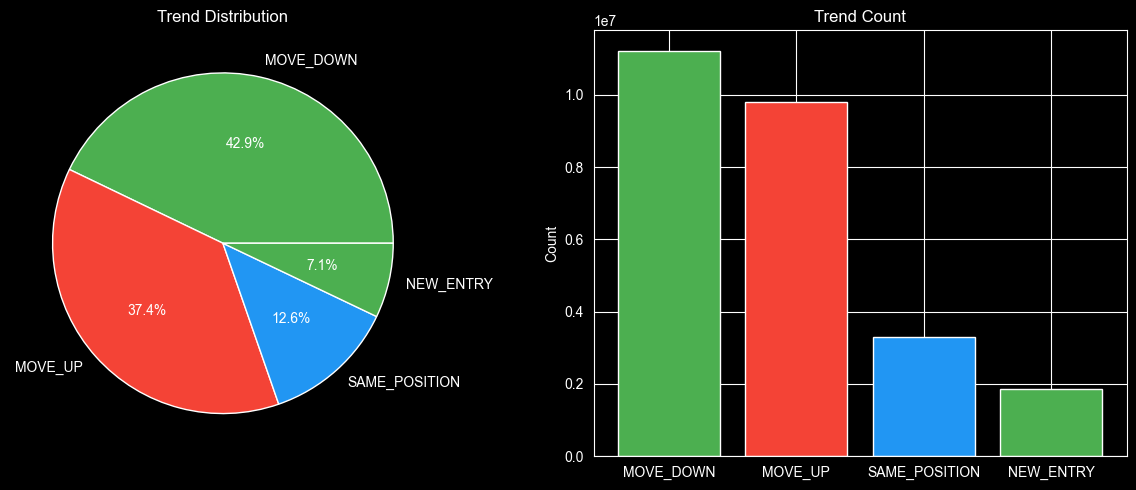

In [110]:
# count how many times each trend appears
trend_counts = music['trend'].value_counts()

# create 2 charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pie chart to show the percentage of each trend
axes[0].pie(trend_counts, labels=trend_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336', '#2196F3'])
axes[0].set_title('Trend Distribution')

# bar chart to show the actual count
axes[1].bar(trend_counts.index, trend_counts.values,
            color=['#4CAF50', '#F44336', '#2196F3'])
axes[1].set_title('Trend Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

This chart shows how songs are distributed across the four trend categories. MOVE_DOWN dominates at 44.3% because most songs lose chart momentum after their peak. MOVE_UP accounts for 38.4% representing songs still gaining traction, while SAME_POSITION and NEW_ENTRY are less common at 11.1% and 6.1% respectively.

### Average Streams by Trend

trend
MOVE_DOWN        40907.900660
MOVE_UP          42651.044473
NEW_ENTRY        25617.165539
SAME_POSITION    77150.478498
Name: streams, dtype: float64


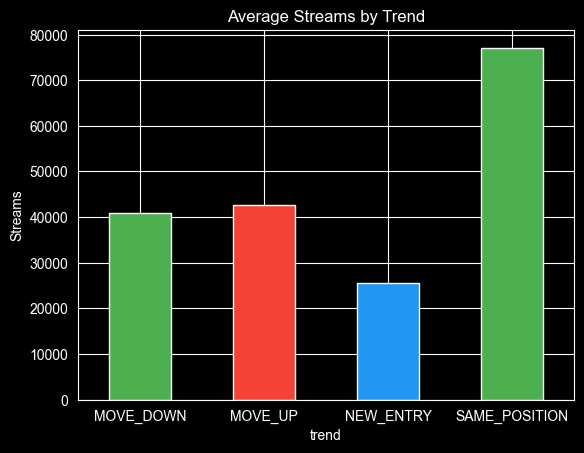

In [111]:
# calculate the average streams for each trend type
avg_streams = music.groupby('trend')['streams'].mean()
print(avg_streams)

# plot it as a bar chart
avg_streams.plot(kind='bar', color=['#4CAF50', '#F44336', '#2196F3'])
plt.title('Average Streams by Trend')
plt.ylabel('Streams')
plt.xticks(rotation=0)  # keep labels horizontal
plt.show()


SAME_POSITION songs have by far the highest average streams at around 100,873, which seems counterintuitive at first. However this makes sense because songs that hold their position are typically already at the top of the charts and accumulate massive consistent streams over time. MOVE_UP and MOVE_DOWN have similar averages around 47,000–49,000, while NEW_ENTRY has the lowest since new songs just entered the chart and haven't had time to build up streams yet. This connects to the distribution analysis — SAME_POSITION is the rarest category but the most stream-heavy, confirming that a small number of dominant songs hold their position while the majority of songs cycle through the charts with moderate streams.

### Trend by Region

trend           MOVE_DOWN  MOVE_UP  NEW_ENTRY  SAME_POSITION
region                                                      
Argentina          192261   164750      27652          70645
Australia          193299   167338      29099          63367
Austria            199124   173195      37004          45270
Brazil             193647   175577      28358          56857
Canada             195529   170082      29091          57577
Global             192974   165255      25569          67995
Philippines        189859   165688      21590          72198
Switzerland        194470   173917      40257          40967
United Kingdom     193153   166088      37702          53778
United States      195116   173751      29470          56720


<Figure size 1400x600 with 0 Axes>

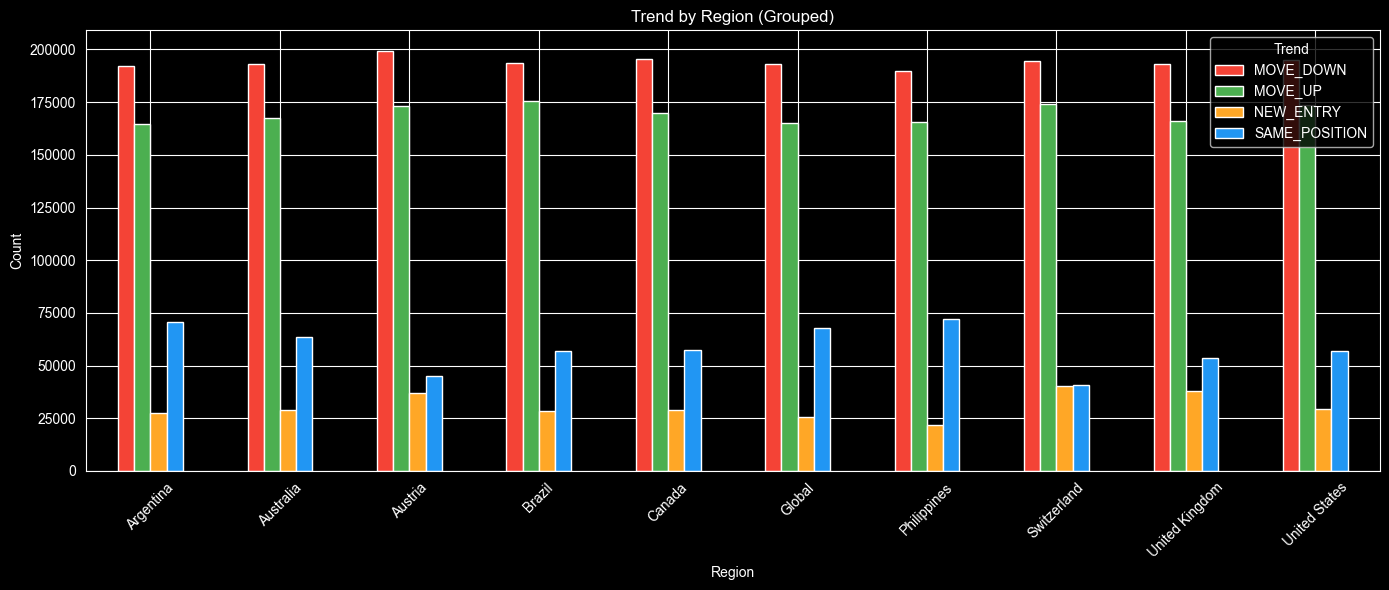

In [123]:
# filter to only top 10 regions by number of entries
top_regions = music['region'].value_counts().head(10).index

# count how many MOVE_UP/DOWN/SAME per region
region_trend = (music[music['region'].isin(top_regions)]
                .groupby(['region', 'trend'])
                .size()
                .unstack(fill_value=0))  # fill_value=0 so missing combos show 0 not NaN
print(region_trend)
# grouped bar chart
plt.figure(figsize=(14, 6))
region_trend.plot(kind='bar', figsize=(14, 6),
                  color=['#F44336', '#4CAF50', '#FFA726', '#2196F3'])
plt.title('Trend by Region (Grouped)')
plt.ylabel('Count')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.legend(title='Trend')
plt.tight_layout()
plt.show()

The grouped bar chart shows the trend distribution across the top 10 regions. In every country the pattern is consistent — MOVE_DOWN is always the highest bar followed by MOVE_UP, SAME_POSITION and NEW_ENTRY. This confirms that the trend behavior is a global pattern rather than something specific to certain regions. One minor exception is Chile which has a noticeably higher SAME_POSITION count compared to other countries, suggesting its charts are slightly more stable. Austria has the highest MOVE_DOWN count meaning its charts rotate the fastest with songs losing position more frequently.

### Trend by Year

trend  MOVE_DOWN  MOVE_UP  NEW_ENTRY  SAME_POSITION
year                                               
2017     1827051  1659437     380681         533976
2018     2091588  1826302     390328         554798
2019     2338663  2018183     360471         695341
2020     2493141  2181683     374519         743787
2021     2469976  2115438     347638         770484


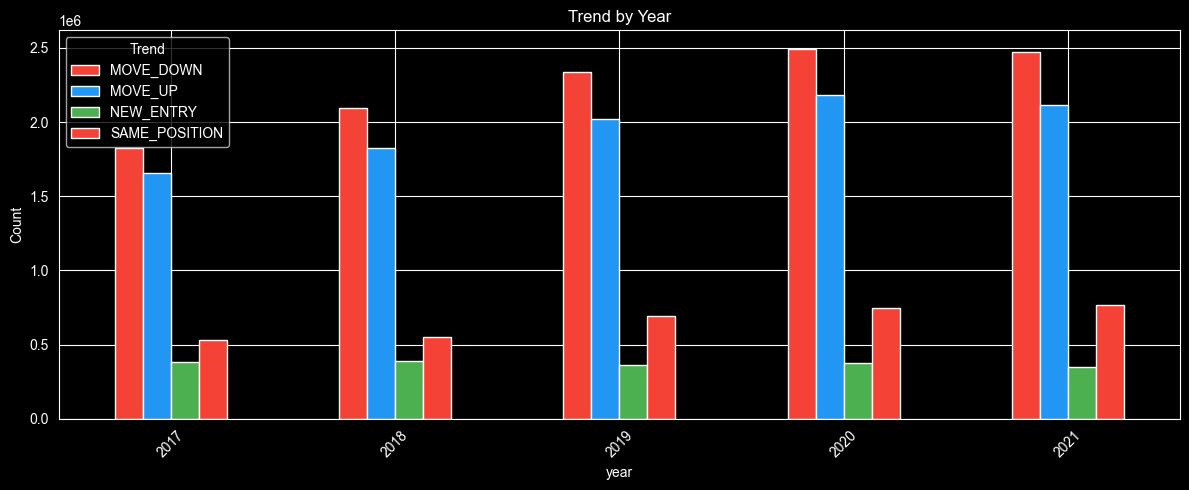

In [131]:
# group by year and trend then count
year_trend = music.groupby(['year', 'trend']).size().unstack(fill_value=0)
print(year_trend)

# bar chart per year
year_trend.plot(kind='bar', figsize=(12, 5),
                color=['#F44336', '#2196F3', '#4CAF50'])
plt.title('Trend by Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Trend')
plt.tight_layout()
plt.show()


The grouped bar chart shows the trend distribution across years. 2018 has by far the most entries with over 1.4 million MOVE_DOWN entries alone, which reflects the volume of data collected that year rather than a change in behavior. 2021 is almost empty with only 98 total entries meaning the dataset cuts off early that year. Despite the difference in volume, the trend pattern within each year stays consistent — MOVE_DOWN is always the highest followed by MOVE_UP, SAME_POSITION and NEW_ENTRY. This suggests that chart behavior did not change significantly over time, the dataset coverage did.

### Artists with Most MOVE_UP

artist
Ed Sheeran         141726
Billie Eilish       91929
Post Malone         79308
Dua Lipa            72138
Bad Bunny           70941
Imagine Dragons     64045
Ariana Grande       63831
XXXTENTACION        59751
Drake               57007
The Weeknd          53483
dtype: int64


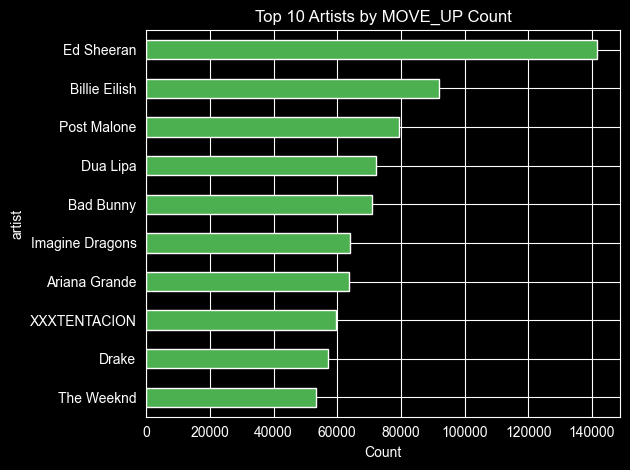

In [125]:
# filter only MOVE_UP rows then count per artist
top_moveup = (music[music['trend'] == 'MOVE_UP']
              .groupby('artist')
              .size()
              .sort_values(ascending=False)
              .head(10))
print(top_moveup)

# horizontal bar chart
top_moveup.plot(kind='barh', color='#4CAF50')
plt.title('Top 10 Artists by MOVE_UP Count')
plt.xlabel('Count')
plt.gca().invert_yaxis()  # put the highest value at the top
plt.tight_layout()
plt.show()


Ed Sheeran leads with the highest MOVE_UP count at 45,889, followed by Post Malone and XXXTENTACION. However this metric favors artists with more total chart appearances rather than measuring actual momentum. An artist appearing in 70 countries every week will naturally accumulate more MOVE_UP entries than one who only charts in a few regions. This should be interpreted as a measure of global chart presence rather than pure upward momentum.

### Box Plot - Stream Distribution by Trend

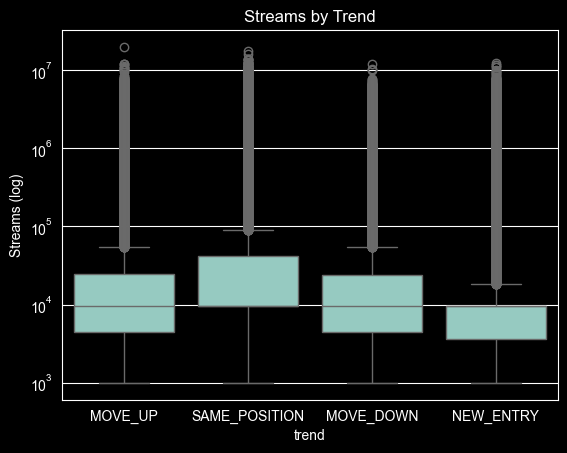

In [126]:
sns.boxplot(data=music, x='trend', y='streams',
            order=['MOVE_UP', 'SAME_POSITION', 'MOVE_DOWN', 'NEW_ENTRY'])
plt.yscale('log')
plt.title('Streams by Trend')
plt.ylabel('Streams (log)')
plt.show()

The box plot uses log scale to show the stream distribution for each trend type. SAME_POSITION has the highest median streams confirming that songs holding their chart position are the most consistently streamed. MOVE_UP and MOVE_DOWN show very similar distributions suggesting that stream count alone does not determine whether a song rises or falls. NEW_ENTRY has the lowest median and the widest spread, meaning new chart entries vary greatly — some debut with high streams while others enter quietly at the bottom of the charts.

## Quartiles

In [127]:
# calculate the 3 quartile boundaries for streams
q1 = music['streams'].quantile(0.25)  # bottom 25%
q2 = music['streams'].quantile(0.50)  # median (middle)
q3 = music['streams'].quantile(0.75)  # top 25%

print(f'Q1: {q1:,.0f}')
print(f'Q2 (median): {q2:,.0f}')
print(f'Q3: {q3:,.0f}')
print(f'IQR: {q3 - q1:,.0f}')  # IQR = interquartile range = Q3 - Q1

Q1: 4,850
Q2 (median): 9,565
Q3: 24,899
IQR: 20,049


In [128]:
# function to assign each row to a quartile based on its stream count
def get_quartile(x):
    if x <= q1:
        return 'Q1'  # lowest 25% of streams
    elif x <= q2:
        return 'Q2'  # 25-50%
    elif x <= q3:
        return 'Q3'  # 50-75%
    else:
        return 'Q4'  # top 25% of streams

# apply the function to every row
music['quartile'] = music['streams'].apply(get_quartile)
# check the counts are roughly equal (should be ~25% each)
music['quartile'].value_counts()


quartile
Q2    9468865
Q1    6543825
Q4    6543247
Q3    3617548
Name: count, dtype: int64

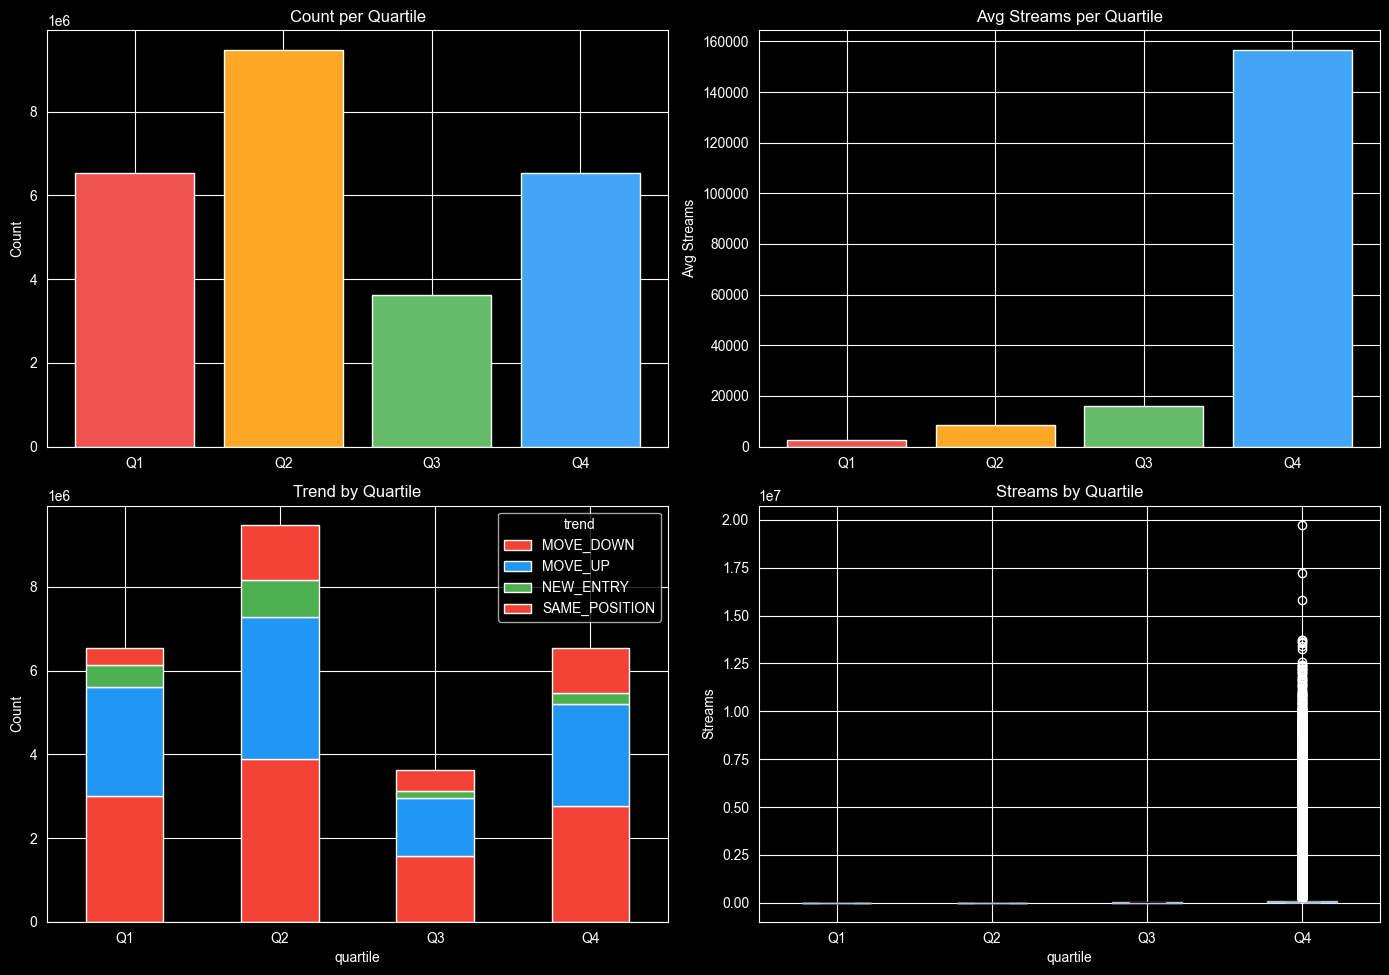

In [129]:
# 4 charts in a 2x2 grid to show different views of the quartiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order = ['Q1', 'Q2', 'Q3', 'Q4']
colors = ['#ef5350', '#FFA726', '#66BB6A', '#42A5F5']

# top left: how many songs are in each quartile
qcounts = music['quartile'].value_counts().reindex(order)
axes[0,0].bar(order, qcounts.values, color=colors)
axes[0,0].set_title('Count per Quartile')
axes[0,0].set_ylabel('Count')

# top right: average streams per quartile
qavg = music.groupby('quartile')['streams'].mean().reindex(order)
axes[0,1].bar(order, qavg.values, color=colors)
axes[0,1].set_title('Avg Streams per Quartile')
axes[0,1].set_ylabel('Avg Streams')

# bottom left: trend breakdown within each quartile
qtrend = music.groupby(['quartile', 'trend']).size().unstack(fill_value=0).reindex(order)
qtrend.plot(kind='bar', stacked=True, ax=axes[1,0],
            color=['#F44336', '#2196F3', '#4CAF50'])
axes[1,0].set_title('Trend by Quartile')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)

# bottom right: box plot to show the spread within each quartile
music.boxplot(column='streams', by='quartile', ax=axes[1,1])
axes[1,1].set_title('Streams by Quartile')
axes[1,1].set_ylabel('Streams')
plt.suptitle('')  # remove the default pandas boxplot title

plt.tight_layout()
plt.show()
